<a href="https://colab.research.google.com/github/williamryanmckee-nwa/Deep-Learning/blob/main/Chars74k_CNN_Character_Recognition_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chars74k Character Recognition with a Deep CNN

## Problem Statement
Build a deep learning convolutional neural network to recognize characters using the **Chars74k EnglishFnt dataset**.

## Objective
Build a neural-network-based classification model with:

- Four convolutional layers
- A **3 × 3 kernel** for every convolutional layer
- **ReLU** activation for every convolutional layer
- Maximum-pooling layers after every two convolutional layers
- Two fully connected hidden layers
- Dropout in the hidden layers
- A Softmax output layer for multi-class character classification

## Evaluation Metrics
The model will be evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

### Dataset
The uploaded archive is `EnglishFnt.tgz.zip`, containing the Chars74k EnglishFnt images. The dataset has 62 character classes (`Sample001`–`Sample062`). The original images are grayscale and are resized to **32 × 32** for CNN training.


## 1. Import Libraries

In [ ]:
import os
import zipfile
import tarfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 2. Extract the Uploaded Dataset

The uploaded ZIP contains `EnglishFnt.tgz`. The following code extracts both archive layers.

**Important:** If you run this notebook on another computer, update `ZIP_PATH` to the location of the downloaded archive.


In [ ]:
ZIP_PATH = "/content/EnglishFnt.tgz.zip"

WORK_DIR = Path("/mnt/data/chars74k")
WORK_DIR.mkdir(parents=True, exist_ok=True)

TGZ_PATH = WORK_DIR / "EnglishFnt.tgz"

# Extract .tgz from ZIP
if not TGZ_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extract("EnglishFnt.tgz", WORK_DIR)

# Extract images from .tgz
if not (WORK_DIR / "English").exists():
    with tarfile.open(TGZ_PATH, "r:gz") as tar:
        tar.extractall(WORK_DIR)

DATASET_DIR = WORK_DIR / "English" / "Fnt"

print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Dataset directory: /mnt/data/chars74k/English/Fnt
Dataset exists: True


## 3. Inspect the Dataset

Each directory represents one character class:

```text
English/Fnt/
    Sample001/
    Sample002/
    ...
    Sample062/
```

The common Chars74k EnglishFnt class ordering is:

- Sample001–Sample010 → digits 0–9
- Sample011–Sample036 → uppercase A–Z
- Sample037–Sample062 → lowercase a–z


In [ ]:
characters = (
    list("0123456789")
    + list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")
    + list("abcdefghijklmnopqrstuvwxyz")
)

sample_to_character = {
    f"Sample{i:03d}": char
    for i, char in enumerate(characters, start=1)
}

sample_dirs = sorted(
    [p for p in DATASET_DIR.iterdir() if p.is_dir()],
    key=lambda p: p.name
)

print("Number of classes:", len(sample_dirs))

for p in sample_dirs[:5]:
    print(p.name, "->", sample_to_character.get(p.name, "?"),
          "images:", len(list(p.glob("*.png"))))

print("...")
for p in sample_dirs[-5:]:
    print(p.name, "->", sample_to_character.get(p.name, "?"),
          "images:", len(list(p.glob("*.png"))))


Number of classes: 62
Sample001 -> 0 images: 1016
Sample002 -> 1 images: 1016
Sample003 -> 2 images: 1016
Sample004 -> 3 images: 1016
Sample005 -> 4 images: 1016
...
Sample058 -> v images: 1016
Sample059 -> w images: 1016
Sample060 -> x images: 1016
Sample061 -> y images: 1016
Sample062 -> z images: 1016


## 4. CNN and Training Parameters

The original Chars74k images are larger than necessary for this teaching model. We resize them to **32 × 32 × 1**.

The output layer contains **62 neurons**, one for each character class.


In [ ]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
CHANNELS = 1

NUM_CLASSES = 62

BATCH_SIZE = 64
EPOCHS = 5
RANDOM_SEED = 42

print("Input shape:", (IMG_HEIGHT, IMG_WIDTH, CHANNELS))
print("Number of classes:", NUM_CLASSES)


## 5. Create Training and Validation Sets

An **80/20 split** is used:

- 80% training
- 20% validation

Images are loaded as grayscale and resized to 32 × 32.


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    seed=RANDOM_SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    seed=RANDOM_SEED,
    shuffle=False
)

class_names = train_ds.class_names

print("Number of detected classes:", len(class_names))
print("First classes:", class_names[:10])


Found 62992 files belonging to 62 classes.
Using 50394 files for training.
Found 62992 files belonging to 62 classes.
Using 12598 files for validation.
Number of detected classes: 62
First classes: ['Sample001', 'Sample002', 'Sample003', 'Sample004', 'Sample005', 'Sample006', 'Sample007', 'Sample008', 'Sample009', 'Sample010']


## 6. Normalize Pixel Values

A grayscale pixel ranges from 0 to 255. We scale it to 0–1:

$$
x_{normalized} = \frac{x}{255}
$$


In [ ]:
normalization = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


## 7. Visualize Sample Characters

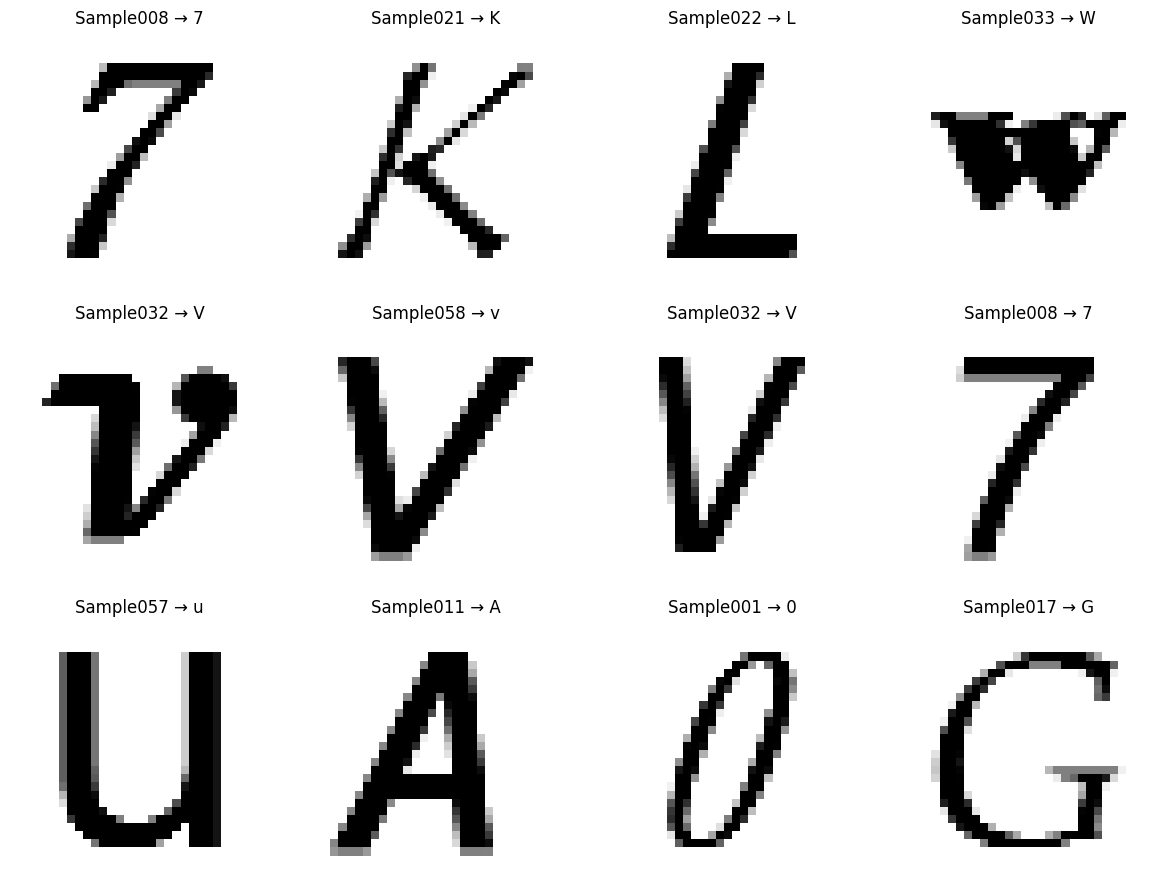

In [ ]:
plt.figure(figsize=(12, 9))

for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        folder_name = class_names[labels[i].numpy()]
        character = sample_to_character.get(folder_name, folder_name)

        plt.title(f"{folder_name} → {character}")
        plt.axis("off")

plt.tight_layout()
plt.show()


# 8. Build the CNN

## Required architecture

The CNN contains exactly four convolutional layers:

1. Conv2D — 32 filters, 3 × 3, ReLU
2. Conv2D — 64 filters, 3 × 3, ReLU
3. Conv2D — 128 filters, 3 × 3, ReLU
4. Conv2D — 256 filters, 3 × 3, ReLU

Max pooling is added after every two convolutional layers.

The two hidden layers are:

- Dense(256) + ReLU + Dropout(0.50)
- Dense(128) + ReLU + Dropout(0.50)

The final layer has 62 neurons with Softmax activation.


In [ ]:
model = tf.keras.Sequential([
    # ----- Convolution Block 1 -----
    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation="relu",
        padding="same",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation="relu",
        padding="same"
    ),

    # Pool after every two convolution layers
    tf.keras.layers.MaxPooling2D((2, 2)),

    # ----- Convolution Block 2 -----
    tf.keras.layers.Conv2D(
        128, (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.Conv2D(
        256, (3, 3),
        activation="relu",
        padding="same"
    ),

    # Second pooling layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # ----- Fully Connected Layers -----
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.50),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.50),

    # ----- Output Layer -----
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,623,294 (17.64 MB)

 Trainable params: 4,623,294 (17.64 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

Because the target is a 62-class classification problem with integer labels:

- **Adam** is used as the optimizer.
- **Sparse categorical cross-entropy** is used as the loss.
- **Accuracy** is tracked during training.


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


## 10. Train the CNN

Early stopping restores the model weights from the epoch with the best validation loss.


In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)


Epoch 1/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 836s 1s/step - accuracy: 0.5009 - loss: 1.8002 - val_accuracy: 0.7326 - val_loss: 0.7589
Epoch 2/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 860s 1s/step - accuracy: 0.7305 - loss: 0.8218 - val_accuracy: 0.8026 - val_loss: 0.6237
Epoch 3/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 826s 1s/step - accuracy: 0.7697 - loss: 0.6536 - val_accuracy: 0.7525 - val_loss: 0.5636
Epoch 4/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 864s 1s/step - accuracy: 0.7921 - loss: 0.5692 - val_accuracy: 0.8268 - val_loss: 0.4845
Epoch 5/5
788/788 ━━━━━━━━━━━━━━━━━━━━ 825s 1s/step - accuracy: 0.8087 - loss: 0.5148 - val_accuracy: 0.8127 - val_loss: 0.4753


## 11. Training and Validation Accuracy

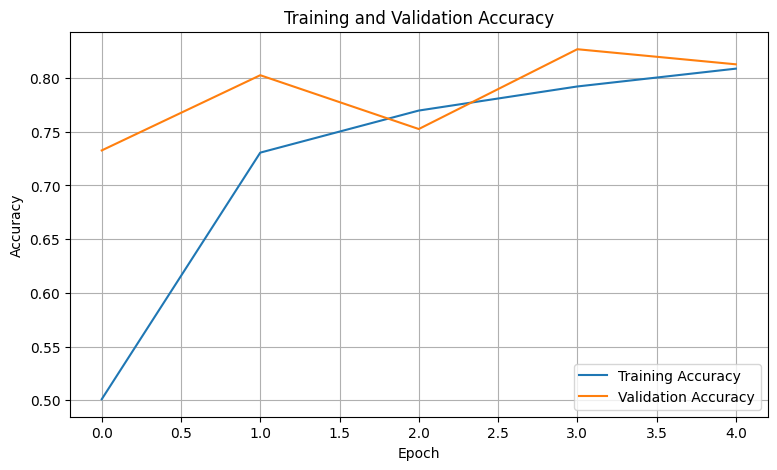

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 12. Training and Validation Loss

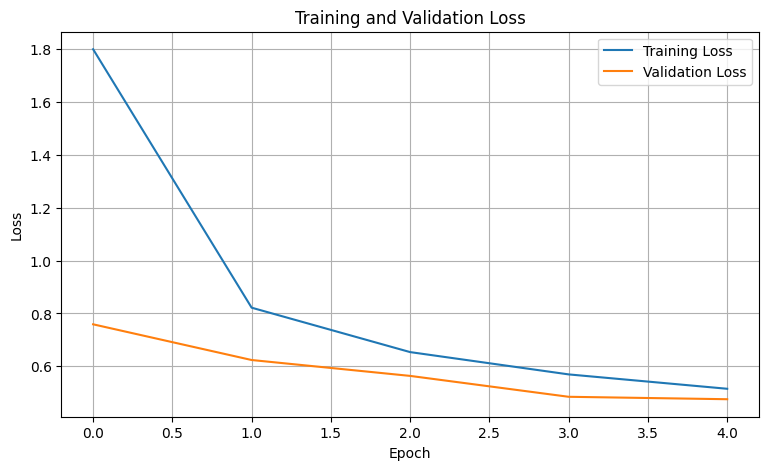

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# 13. Evaluate Validation Loss and Accuracy

In [ ]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


197/197 ━━━━━━━━━━━━━━━━━━━━ 53s 271ms/step - accuracy: 0.8127 - loss: 0.4753
Validation Loss: 0.4753
Validation Accuracy: 0.8127
Validation Accuracy: 81.27%


# 14. Generate Predictions

The Softmax output contains 62 class probabilities. `argmax()` selects the character with the highest probability.


In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Validation samples:", len(y_true))


Validation samples: 12598


# 15. Classification Metrics

### Accuracy
Percentage of all predictions that are correct.

### Precision
For a class, precision measures how many predicted examples of that class are actually correct.

### Recall
For a class, recall measures how many of the actual examples of that class were correctly identified.

### F1-score
The harmonic mean of precision and recall:

$$
F1 = 2 \times \frac{Precision \times Recall}
{Precision + Recall}
$$

**Macro averaging** is used so that every character class contributes equally to the overall metric.


In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true, y_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.8127
Precision: 0.2266
Recall   : 0.1864
F1-score : 0.2016


# 16. Classification Report

The classification report gives precision, recall, F1-score, and support for each of the 62 character classes.


In [ ]:
display_names = [
    sample_to_character.get(name, name)
    for name in class_names
]

print(
    classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=display_names,
        zero_division=0
    )
)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
           A       0.00      0.00      0.00         0
           B       0.00      0.00      0.00         0
           C       0.00      0.00      0.00         0
           D       0.00      0.00      0.00         0
           E       0.00      0.00      0.00         0
           F       0.00      0.00      0.00         0
           G       0.00      0.00      0.00         0
           H       0.00    

# 17. Confusion Matrix

The confusion matrix shows which characters are frequently confused.

Examples of potentially difficult character pairs include:

- `O` vs `0`
- `I` vs `l` vs `1`
- `S` vs `5`
- `Z` vs `2`


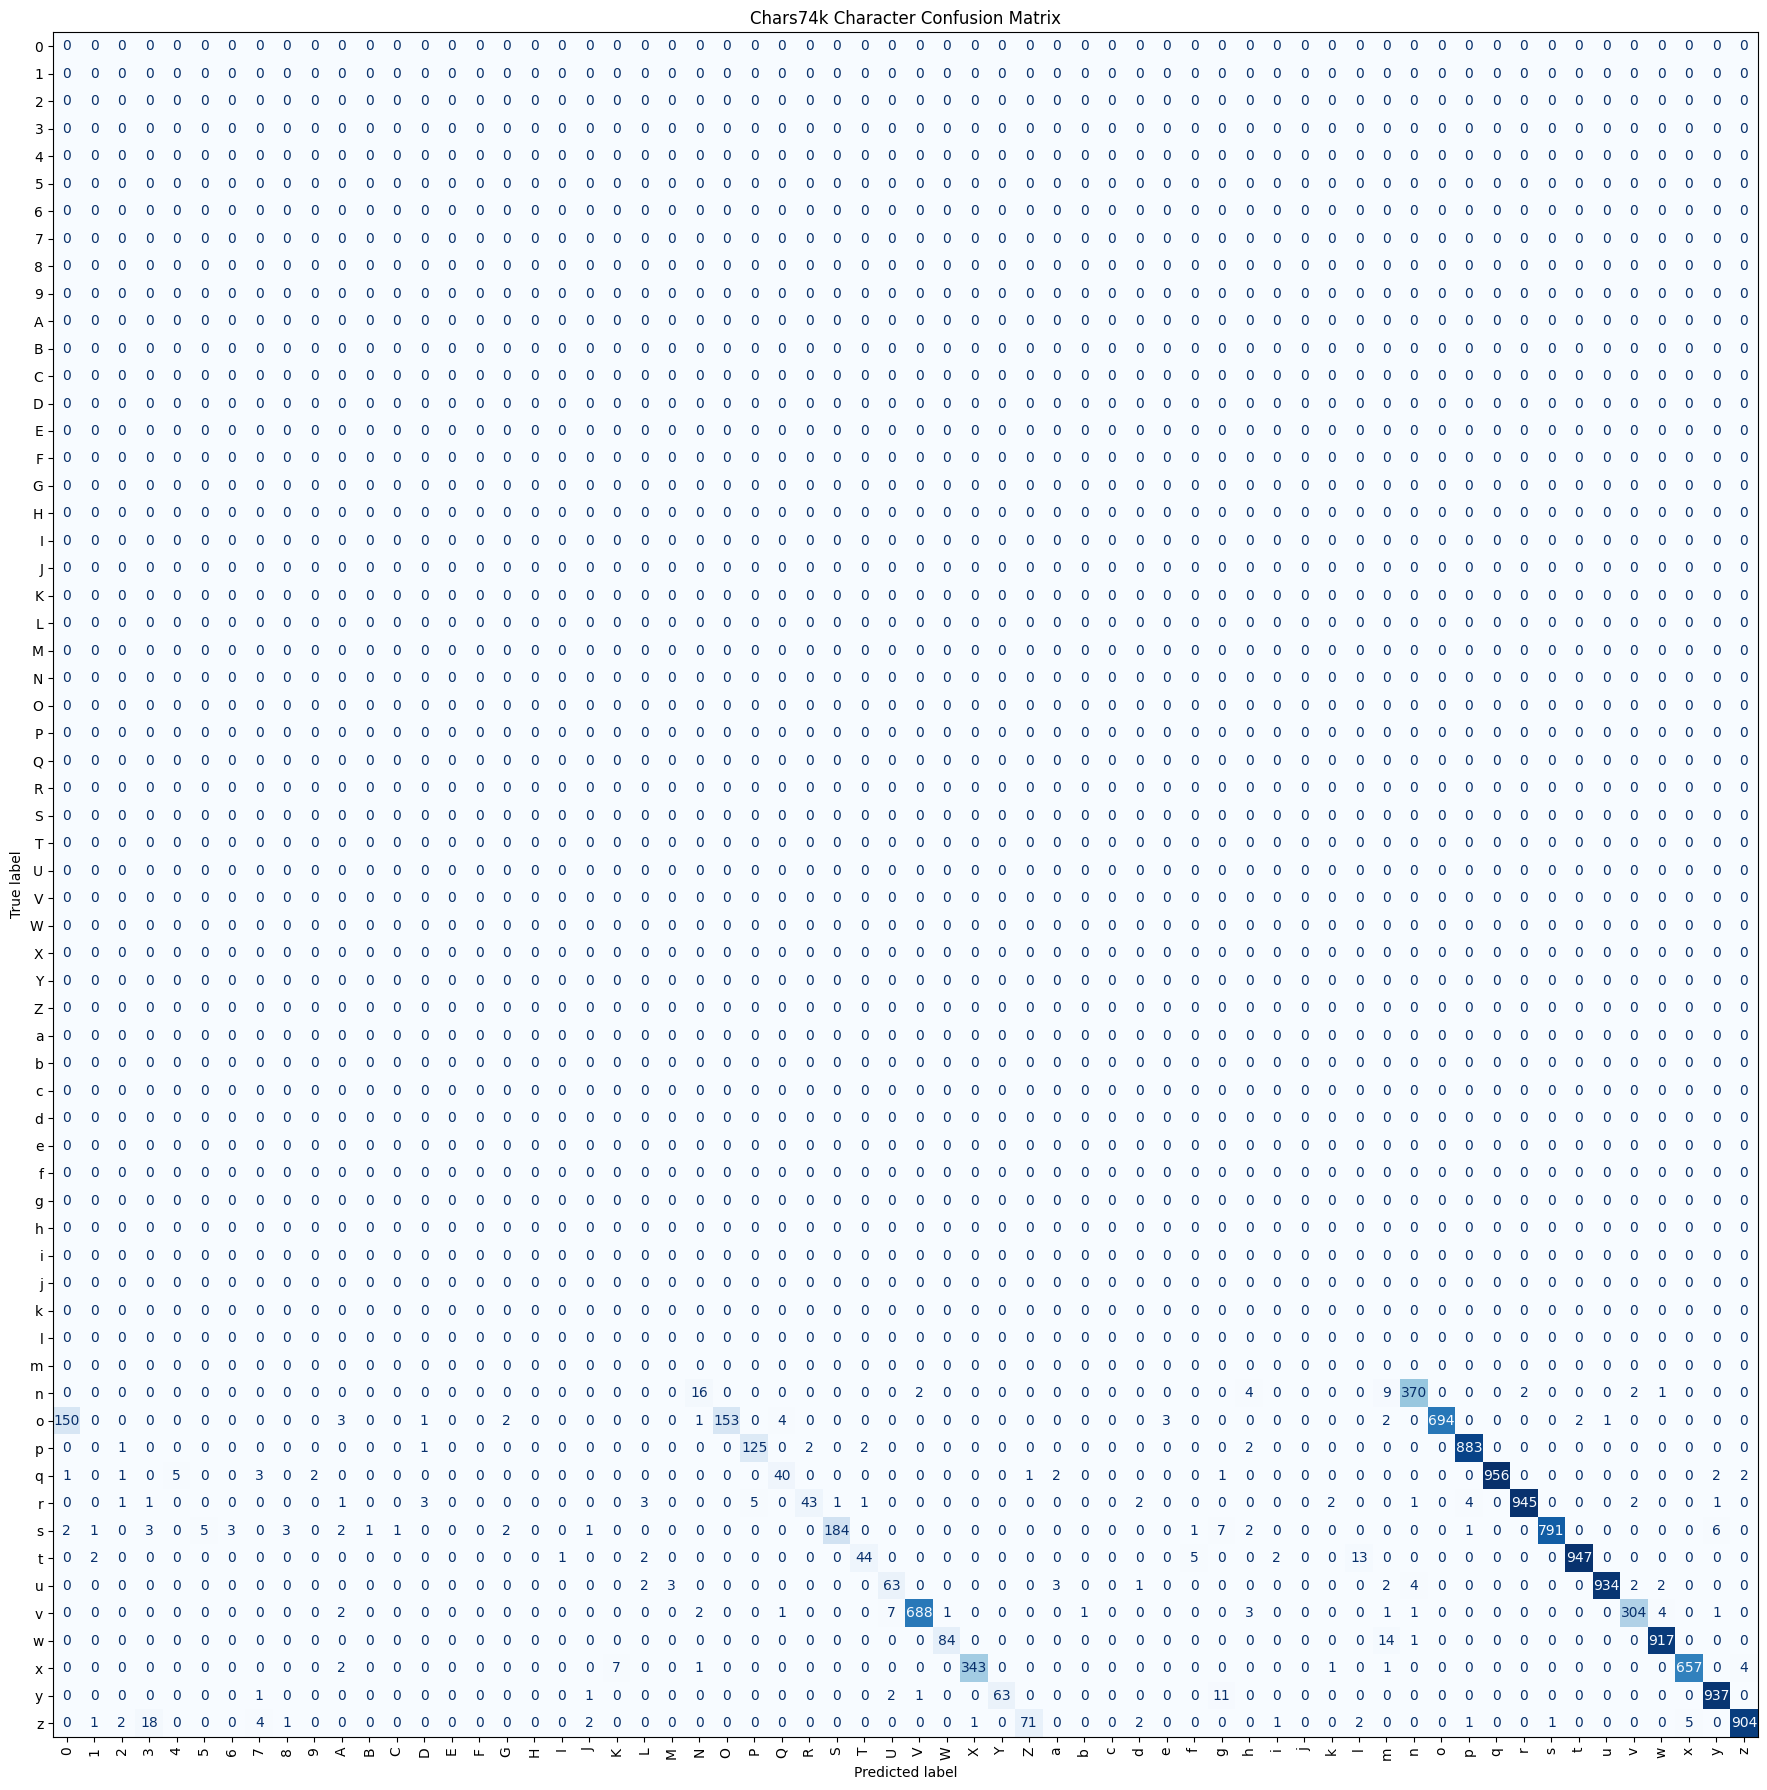

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

fig, ax = plt.subplots(figsize=(18, 18))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_names
)

disp.plot(
    ax=ax,
    xticks_rotation="vertical",
    values_format="d",
    colorbar=False,
    cmap="Blues"
)

plt.title("Chars74k Character Confusion Matrix")
plt.tight_layout()
plt.show()


# 18. Visualize Actual vs Predicted Characters

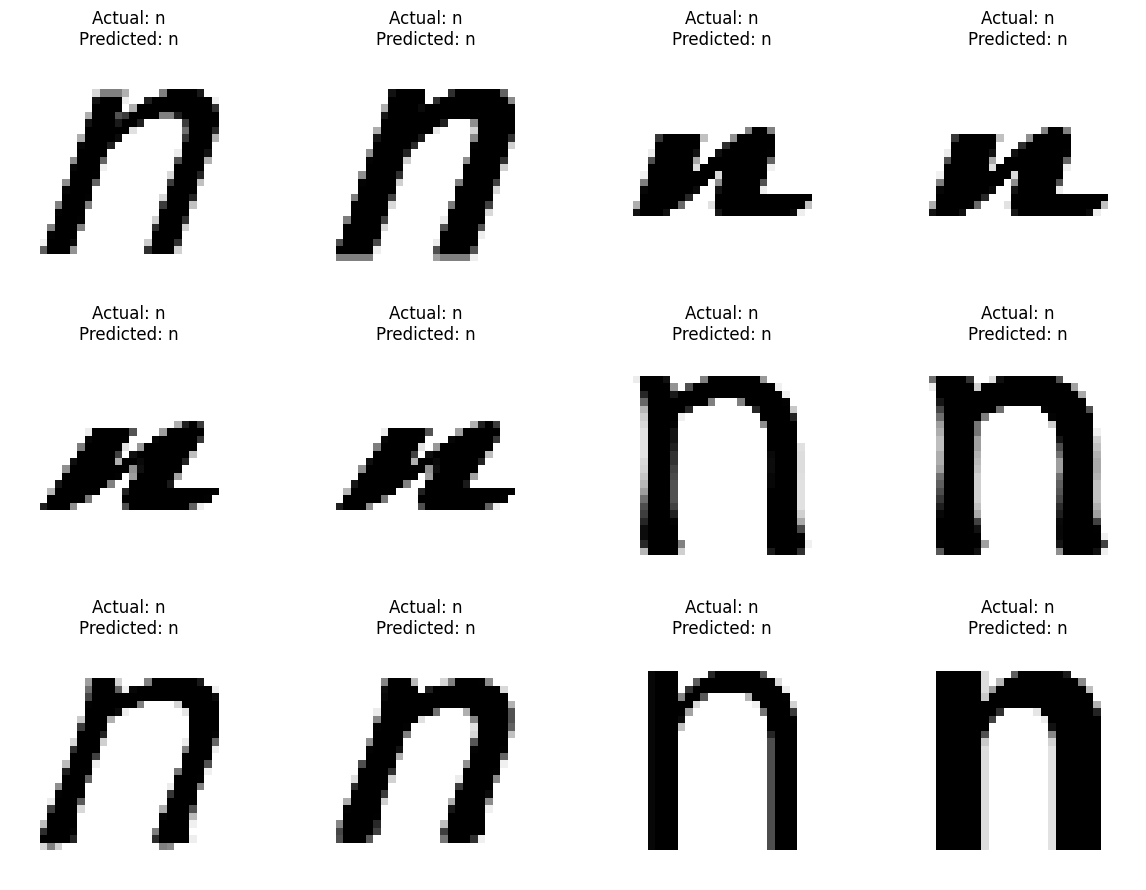

In [ ]:
for images, labels in val_ds.take(1):
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    plt.figure(figsize=(12, 9))

    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        actual = display_names[labels[i].numpy()]
        predicted = display_names[predictions[i]]

        plt.title(
            f"Actual: {actual}\nPredicted: {predicted}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# 19. Save the Trained Model

In [ ]:
MODEL_PATH = "/mnt/data/chars74k_cnn.keras"

model.save(MODEL_PATH)

print("Saved model:", MODEL_PATH)


Saved model: /mnt/data/chars74k_cnn.keras


# 20. Final Architecture Summary

```text
Input: 32 × 32 × 1
       │
       ▼
Conv2D: 32 filters, 3×3, ReLU
       │
       ▼
Conv2D: 64 filters, 3×3, ReLU
       │
       ▼
MaxPooling: 2×2
       │
       ▼
Conv2D: 128 filters, 3×3, ReLU
       │
       ▼
Conv2D: 256 filters, 3×3, ReLU
       │
       ▼
MaxPooling: 2×2
       │
       ▼
Flatten
       │
       ▼
Dense: 256, ReLU
       │
       ▼
Dropout: 0.50
       │
       ▼
Dense: 128, ReLU
       │
       ▼
Dropout: 0.50
       │
       ▼
Dense: 62, Softmax
       │
       ▼
Predicted Character
```

## Requirement Checklist

| Requirement | Implementation |
|---|---|
| Chars74k dataset | EnglishFnt |
| Character classification | 62 classes |
| Four convolution layers | Yes |
| 3 × 3 kernel | All 4 Conv2D layers |
| ReLU activation | All 4 Conv2D layers |
| Max pooling after every other convolution | After Conv2 and Conv4 |
| Two hidden layers | Dense 256 and Dense 128 |
| Dropout | 0.50 after each hidden layer |
| Output activation | Softmax |
| Accuracy | Yes |
| Precision | Yes |
| Recall | Yes |
| F1-score | Yes |
| Confusion matrix | Yes |


# 21. Interpretation Guide

After running the notebook, use the metrics together rather than relying on accuracy alone.

- **High accuracy + high macro precision/recall/F1:** performance is relatively consistent across classes.
- **High accuracy but lower macro F1:** some character classes may be performing substantially worse than others.
- **Confusion matrix:** identify specific characters that the CNN frequently confuses.
- **Training vs validation curves:** a large gap between training and validation performance can indicate overfitting.

The actual numerical results should be reported after the notebook is trained on the dataset.
